# Cuaderno 3 — Modelado y evaluación

**Tesis:** Predicción del Punto de Equilibrio de Flujo de Caja en Empresas de Crecimiento  
**Autores:** Andrea Meneses · Juan Ramos  
**Universidad EAFIT · 2026**

---

## Objetivo

Entrenar, afinar y evaluar modelos de machine learning para predecir si una empresa alcanzará el punto de equilibrio de flujo de caja en los próximos 4 trimestres.

---

## Estrategia de validación: Walk-forward

Los datos financieros son series de tiempo — un trimestre depende de los anteriores. Usar validación cruzada aleatoria (k-fold estándar) introduciría **data leakage**: el modelo vería datos futuros durante el entrenamiento, inflando artificialmente las métricas.

La solución es **walk-forward validation con ventana expansiva**:
- El entrenamiento siempre comienza en 2008
- El año de test avanza uno a uno: 2016, 2017, ..., 2024
- El modelo nunca ve datos del futuro durante el entrenamiento
- Se generan 9 folds de test, cada uno con más de 1.000 observaciones

Se usa ventana **expansiva** (no deslizante) para aprovechar la mayor cantidad de datos históricos disponibles en cada fold.

---

## Métrica principal: AUC-PR

El **AUC-PR** (área bajo la curva Precision-Recall) mide qué tan bien el modelo ordena las empresas de mayor a menor probabilidad de alcanzar el breakeven, para todos los umbrales de decisión posibles.

- **Precision**: de las empresas que el modelo predijo que alcanzarían el breakeven, ¿cuántas realmente lo hicieron?
- **Recall**: de todas las empresas que realmente alcanzaron el breakeven, ¿cuántas identificó el modelo?

Un modelo aleatorio tiene AUC-PR ≈ 0.482 (igual a la proporción de Y=1 en el dataset). Un modelo perfecto tiene AUC-PR = 1.0.

---

## Benchmarks

| Benchmark | AUC-PR | Descripción |
|---|---|---|
| Aleatorio | 0.482 | Predice Y=1 con probabilidad igual a la proporción base |
| Persistencia | 0.482 | Predice que el estado actual persiste (siempre Y=0) |
| Piotroski F-Score | 0.487 | Score de señales financieras binarias — estándar en value investing |

El Piotroski F-Score apenas supera el azar para nuestro universo — confirma que los métodos tradicionales de value investing no están diseñados para empresas de crecimiento en etapa de quema de caja.

---

## Evolución del modelado

El cuaderno sigue una progresión deliberada de complejidad creciente:

1. Benchmarks y modelos base con parámetros por defecto
2. Afinación de hiperparámetros con GridSearchCV
3. Modelos modernos: XGBoost y LightGBM
4. Features temporales: cambios trimestrales y rezagos
5. Ensemble: combinación de modelos complementarios

---

## Resultado principal

El modelo final — **Ensemble de Random Forest y LightGBM con features de momentum** — alcanza un AUC-PR promedio de **0.762** sobre 9 folds de walk-forward validation, representando una mejora del **58% sobre el baseline aleatorio** y superando ampliamente el Piotroski F-Score.

Este resultado es consistente con la literatura de machine learning aplicado a predicción financiera (Gu, Kelly & Xiu, 2020) y justifica el uso de modelos de ML sobre métodos tradicionales para el universo de empresas de crecimiento small/mid cap del Russell 2500.

## 1. Configuración inicial

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                              classification_report, precision_score, recall_score)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

# Identidad visual
juan_colors = ['#101B4B', '#545E85', '#A3A8B2', '#E7E7E7', '#0F19C9', '#F6D673']
FUENTE = "STIXGeneral"

def estilo_ax(ax, orientacion="vertical"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    if orientacion == "vertical":
        ax.spines["left"].set_visible(False)
        ax.yaxis.grid(True, linestyle="-", color=juan_colors[3], linewidth=0.8)
        ax.xaxis.grid(False)
    else:
        ax.spines["bottom"].set_visible(False)
        ax.xaxis.grid(True, linestyle="-", color=juan_colors[3], linewidth=0.8)
        ax.yaxis.grid(False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

# Cargar dataset
df = pd.read_csv("../datos/procesados/dataset_modelo.csv")
df["end"] = pd.to_datetime(df["end"])
df["ano"] = df["end"].dt.year

# Limpiar infinitos
no_features = ["ticker", "sector", "bolsa", "end", "ano", "fcf_promedio_futuro", "Y"]
features    = [c for c in df.columns if c not in no_features]
df[features] = df[features].replace([np.inf, -np.inf], np.nan)

print(f"Dataset cargado: {df.shape}")
print(f"Features base: {len(features)}")
print(f"Empresas: {df['ticker'].nunique():,}")
print(f"Y=1: {df['Y'].mean()*100:.1f}%")

Dataset cargado: (27382, 56)
Features base: 49
Empresas: 1,608
Y=1: 48.2%


## 2. Estructura del walk-forward

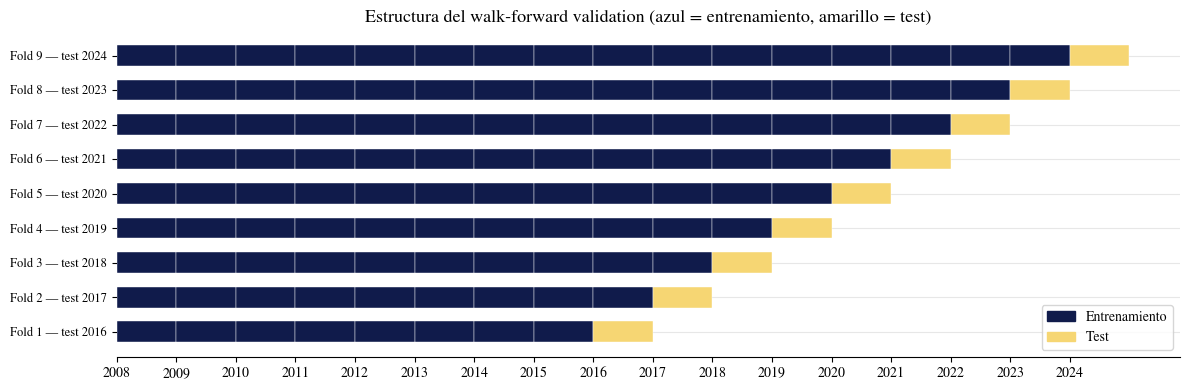

Fold   Año test    Train obs   Test obs  Train empresas  Test empresas
-----------------------------------------------------------------
1      2016            6,686      1,144             884            746
2      2017            7,830      1,758             993          1,017
3      2018            9,588      1,985           1,107          1,083
4      2019           11,573      2,220           1,183          1,214
5      2020           13,793      2,427           1,291          1,288
6      2021           16,220      2,786           1,446          1,367
7      2022           19,006      3,037           1,498          1,430
8      2023           22,043      2,614           1,538          1,373
9      2024           24,657      2,694           1,582          1,455


In [7]:
# Definir folds
folds = []
for ano_test in range(2016, 2025):
    train = df[df["ano"] < ano_test].copy()
    test  = df[df["ano"] == ano_test].copy()
    folds.append((ano_test, train, test))

# Gráfico — estructura de folds
fig, ax = plt.subplots(figsize=(12, 4))
estilo_ax(ax, "vertical")

anos_todos = list(range(2008, 2025))
for i, (ano_test, train, test) in enumerate(folds):
    anos_train = sorted(train["ano"].unique())
    for ano in anos_train:
        ax.barh(i, 1, left=ano - 2008, color=juan_colors[0],
                height=0.6, edgecolor="white", linewidth=0.3)
    ax.barh(i, 1, left=ano_test - 2008, color=juan_colors[5],
            height=0.6, edgecolor="white", linewidth=0.3)

ax.set_xticks(range(len(anos_todos)))
ax.set_xticklabels(anos_todos, fontfamily=FUENTE)
ax.set_yticks(range(9))
ax.set_yticklabels([f"Fold {i+1} — test {ano}" for i, (ano, _, _) in enumerate(folds)],
                   fontfamily=FUENTE, fontsize=9)
ax.set_title("Estructura del walk-forward validation (azul = entrenamiento, amarillo = test)",
             fontfamily=FUENTE, fontsize=13)

patch_train = mpatches.Patch(color=juan_colors[0], label="Entrenamiento")
patch_test  = mpatches.Patch(color=juan_colors[5], label="Test")
ax.legend(handles=[patch_train, patch_test], prop={"family": FUENTE})
plt.tight_layout()
plt.show()

print(f"{'Fold':<6} {'Año test':<10} {'Train obs':>10} {'Test obs':>10} {'Train empresas':>15} {'Test empresas':>14}")
print("-"*65)
for i, (ano_test, train, test) in enumerate(folds):
    print(f"{i+1:<6} {ano_test:<10} {len(train):>10,} {len(test):>10,} "
          f"{train['ticker'].nunique():>15,} {test['ticker'].nunique():>14,}")

## 3. Benchmarks

Antes de entrenar ningún modelo de ML, establecemos los benchmarks que deben ser superados para justificar la complejidad adicional.

In [9]:
def piotroski_simplificado(df):
    """Versión simplificada del F-Score de Piotroski.
    Cada señal financiera positiva suma 1 punto.
    Predice Y=1 si el score >= 5.
    """
    score = pd.Series(0, index=df.index)
    score += (df["utilidad_neta"]    > 0).astype(int)
    score += (df["fcf_operativo"]    > 0).astype(int)
    score += (df["utilidad_neta"]    > df["utilidad_neta"].shift(1)).astype(int)
    score += (df["ratio_corriente"]  > 1).astype(int)
    score += (df["ratio_deuda"]      < df["ratio_deuda"].shift(1)).astype(int)
    score += (df["emision_acciones"] <= 0).astype(int)
    score += (df["margen_bruto"]     > df["margen_bruto"].shift(1)).astype(int)
    score += (df["rotacion_activos"] > df["rotacion_activos"].shift(1)).astype(int)
    return (score >= 5).astype(float)

df = df.sort_values(["ticker", "end"])
df["pred_piotroski"]    = df.groupby("ticker", group_keys=False, observed=True).apply(
    piotroski_simplificado, include_groups=False).values
df["pred_persistencia"] = 0.0

# Métricas
auc_piotroski    = average_precision_score(df["Y"], df["pred_piotroski"])
auc_persistencia = average_precision_score(df["Y"], df["pred_persistencia"])
auc_aleatorio    = df["Y"].mean()

pct_predice_si = df["pred_piotroski"].mean() * 100
n_predice_si   = int(df["pred_piotroski"].sum())
precision_pio  = precision_score(df["Y"], df["pred_piotroski"])
recall_pio     = recall_score(df["Y"], df["pred_piotroski"])
n_total        = len(df)
n_breakeven    = int(df["Y"].sum())

print(f"AUC-PR Aleatorio:    {auc_aleatorio:.3f}  ← piso mínimo, igual a la proporción de Y=1 en el dataset")
print(f"AUC-PR Persistencia: {auc_persistencia:.3f}  ← predecir siempre Y=0 no aporta nada")
print(f"AUC-PR Piotroski:    {auc_piotroski:.3f}  ← apenas supera el azar")
print()
print(f"El Piotroski predice Y=1 en {pct_predice_si:.1f}% de los casos:")
print(f"  → De {n_total:,} observaciones totales, selecciona solo {n_predice_si:,} como candidatas a breakeven")
print(f"  → De esas {n_predice_si:,} que selecciona, el {precision_pio*100:.0f}% realmente alcanzó el breakeven (Precision={precision_pio:.2f})")
print(f"  → Pero hay {n_breakeven:,} empresas-trimestre que realmente alcanzaron el breakeven en el dataset")
print(f"     El Piotroski solo identificó el {recall_pio*100:.0f}% de ellas — se perdió el {(1-recall_pio)*100:.0f}% (Recall={recall_pio:.2f})")

AUC-PR Aleatorio:    0.482  ← piso mínimo, igual a la proporción de Y=1 en el dataset
AUC-PR Persistencia: 0.482  ← predecir siempre Y=0 no aporta nada
AUC-PR Piotroski:    0.487  ← apenas supera el azar

El Piotroski predice Y=1 en 2.7% de los casos:
  → De 27,382 observaciones totales, selecciona solo 732 como candidatas a breakeven
  → De esas 732 que selecciona, el 62% realmente alcanzó el breakeven (Precision=0.62)
  → Pero hay 13,209 empresas-trimestre que realmente alcanzaron el breakeven en el dataset
     El Piotroski solo identificó el 3% de ellas — se perdió el 97% (Recall=0.03)


El Piotroski es muy selectivo pero casi ciego. Funciona para las pocas empresas que escoge, pero ignora la gran mayoría de oportunidades reales de breakeven. Fue diseñado para empresas de valor consolidadas, no para empresas de crecimiento en etapa de quema de caja como las del Russell 2500.

## 4. Modelos base — parámetros por defecto

In [9]:
modelos = {
    "Regresión Logística": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
}

resultados = {nombre: [] for nombre in modelos}

for i, (ano_test, train, test) in enumerate(folds):
    X_train = train[features].values
    y_train = train["Y"].values
    X_test  = test[features].values
    y_test  = test["Y"].values

    for nombre, pipeline in modelos.items():
        pipeline.fit(X_train, y_train)
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        auc_pr = average_precision_score(y_test, y_prob)
        resultados[nombre].append({
            "ano_test": ano_test, "auc_pr": auc_pr,
            "y_test": y_test, "y_prob": y_prob
        })

    print(f"Fold {i+1}/9 — {ano_test} ✓")

df_resultados = []
for nombre, folds_res in resultados.items():
    for fold in folds_res:
        df_resultados.append({"modelo": nombre, "ano_test": fold["ano_test"],
                               "auc_pr": fold["auc_pr"], "tipo": "base"})
df_resultados = pd.DataFrame(df_resultados)

print("\nAUC-PR modelos base:")
print(df_resultados.groupby("modelo")["auc_pr"].agg(["mean","std","min","max"]).round(3).to_string())

Fold 1/9 — 2016 ✓
Fold 2/9 — 2017 ✓
Fold 3/9 — 2018 ✓
Fold 4/9 — 2019 ✓
Fold 5/9 — 2020 ✓
Fold 6/9 — 2021 ✓
Fold 7/9 — 2022 ✓
Fold 8/9 — 2023 ✓
Fold 9/9 — 2024 ✓

AUC-PR modelos base:
                      mean    std    min    max
modelo                                         
Gradient Boosting    0.746  0.067  0.617  0.806
Random Forest        0.748  0.078  0.589  0.806
Regresión Logística  0.661  0.057  0.549  0.723


## 5. Afinación de hiperparámetros

Los modelos con parámetros por defecto ya superan ampliamente los benchmarks. La afinación busca extraer el máximo rendimiento posible.

Se usa **GridSearchCV con TimeSeriesSplit** para respetar el orden temporal durante la búsqueda — nunca se usa información futura para seleccionar hiperparámetros.

> ⚠️ **Esta celda tarda ~35 minutos.** Solo es necesario ejecutarla una vez.

In [10]:
df_tune = df[df["ano"] <= 2022].copy()
X_tune  = df_tune[features].values
y_tune  = df_tune["Y"].values
tscv    = TimeSeriesSplit(n_splits=5)

# Random Forest
gs_rf = GridSearchCV(
    Pipeline([("imputer", SimpleImputer(strategy="median")),
              ("model",   RandomForestClassifier(random_state=42, n_jobs=-1))]),
    {"model__n_estimators": [100, 200], "model__max_depth": [None, 10, 20],
     "model__min_samples_leaf": [1, 5, 10]},
    cv=tscv, scoring="average_precision", n_jobs=-1, verbose=1
)
gs_rf.fit(X_tune, y_tune)
print(f"Mejores params RF: {gs_rf.best_params_}")
print(f"AUC-PR CV RF: {gs_rf.best_score_:.3f}")

# Gradient Boosting
gs_gb = GridSearchCV(
    Pipeline([("imputer", SimpleImputer(strategy="median")),
              ("model",   GradientBoostingClassifier(random_state=42))]),
    {"model__n_estimators": [100, 200], "model__max_depth": [3, 5],
     "model__learning_rate": [0.05, 0.1, 0.2], "model__min_samples_leaf": [5, 10]},
    cv=tscv, scoring="average_precision", n_jobs=-1, verbose=1
)
gs_gb.fit(X_tune, y_tune)
print(f"\nMejores params GB: {gs_gb.best_params_}")
print(f"AUC-PR CV GB: {gs_gb.best_score_:.3f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits


Mejores params RF: {'model__max_depth': None, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}
AUC-PR CV RF: 0.760
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Mejores params GB: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__n_estimators': 100}
AUC-PR CV GB: 0.751


In [11]:
# Walk-forward con modelos afinados
modelos_afinados = {
    "Random Forest (afinado)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   RandomForestClassifier(
            n_estimators=200, max_depth=None, min_samples_leaf=10,
            random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting (afinado)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   GradientBoostingClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.05,
            min_samples_leaf=10, random_state=42))
    ]),
}

resultados_afinados = {nombre: [] for nombre in modelos_afinados}

for i, (ano_test, train, test) in enumerate(folds):
    for nombre, pipeline in modelos_afinados.items():
        pipeline.fit(train[features].values, train["Y"].values)
        y_prob = pipeline.predict_proba(test[features].values)[:, 1]
        auc_pr = average_precision_score(test["Y"].values, y_prob)
        resultados_afinados[nombre].append({
            "ano_test": ano_test, "auc_pr": auc_pr,
            "y_test": test["Y"].values, "y_prob": y_prob
        })
    print(f"Fold {i+1}/9 — {ano_test} ✓")

for nombre, folds_res in resultados_afinados.items():
    vals = [f["auc_pr"] for f in folds_res]
    print(f"{nombre:<35} media={np.mean(vals):.3f}  std={np.std(vals):.3f}")

Fold 1/9 — 2016 ✓
Fold 2/9 — 2017 ✓
Fold 3/9 — 2018 ✓
Fold 4/9 — 2019 ✓
Fold 5/9 — 2020 ✓
Fold 6/9 — 2021 ✓
Fold 7/9 — 2022 ✓
Fold 8/9 — 2023 ✓
Fold 9/9 — 2024 ✓
Random Forest (afinado)             media=0.758  std=0.072
Gradient Boosting (afinado)         media=0.755  std=0.064


## 6. Modelos modernos: XGBoost y LightGBM

XGBoost y LightGBM son variantes optimizadas de Gradient Boosting con implementaciones más eficientes. En la práctica entrenan hasta 100x más rápido que el GB estándar de scikit-learn manteniendo resultados comparables.

In [12]:
modelos_avanzados = {
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   XGBClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.05,
            min_child_weight=10, random_state=42,
            eval_metric="aucpr", verbosity=0))
    ]),
    "LightGBM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   LGBMClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.05,
            min_child_samples=10, random_state=42, verbose=-1))
    ]),
}

resultados_avanzados = {nombre: [] for nombre in modelos_avanzados}

for i, (ano_test, train, test) in enumerate(folds):
    for nombre, pipeline in modelos_avanzados.items():
        pipeline.fit(train[features].values, train["Y"].values)
        y_prob = pipeline.predict_proba(test[features].values)[:, 1]
        auc_pr = average_precision_score(test["Y"].values, y_prob)
        resultados_avanzados[nombre].append({
            "ano_test": ano_test, "auc_pr": auc_pr,
            "y_test": test["Y"].values, "y_prob": y_prob
        })
    print(f"Fold {i+1}/9 — {ano_test} ✓")

for nombre, folds_res in resultados_avanzados.items():
    vals = [f["auc_pr"] for f in folds_res]
    print(f"{nombre:<35} media={np.mean(vals):.3f}  std={np.std(vals):.3f}")

Fold 1/9 — 2016 ✓
Fold 2/9 — 2017 ✓
Fold 3/9 — 2018 ✓
Fold 4/9 — 2019 ✓
Fold 5/9 — 2020 ✓
Fold 6/9 — 2021 ✓
Fold 7/9 — 2022 ✓
Fold 8/9 — 2023 ✓
Fold 9/9 — 2024 ✓
XGBoost                             media=0.753  std=0.065
LightGBM                            media=0.755  std=0.064


## 7. Features temporales: momentum y rezagos

Las variables originales capturan el estado de la empresa en un momento dado, pero no su **tendencia**. Agregamos dos tipos de features temporales:

- **Cambios trimestrales** (`_cambio`, `_cambio_pct`): capturan si la empresa está mejorando o deteriorándose
- **Rezagos** (`_lag2`, `_lag4`): capturan el estado de 2 y 4 trimestres atrás

Solo se conservan features con cobertura > 50% para evitar introducir ruido por imputación excesiva.

In [13]:
df = df.sort_values(["ticker", "end"])

vars_momentum = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate",
                 "margen_bruto", "ingresos"]
vars_rezago   = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate"]

for var in vars_momentum:
    df[f"{var}_cambio"]     = df.groupby("ticker", observed=True)[var].diff()
    df[f"{var}_cambio_pct"] = df.groupby("ticker", observed=True)[var].pct_change()

for var in vars_rezago:
    df[f"{var}_lag2"] = df.groupby("ticker", observed=True)[var].shift(2)
    df[f"{var}_lag4"] = df.groupby("ticker", observed=True)[var].shift(4)

todas_nuevas = ([f"{v}_cambio" for v in vars_momentum] +
                [f"{v}_cambio_pct" for v in vars_momentum] +
                [f"{v}_lag{l}" for v in vars_rezago for l in [2, 4]])

df[todas_nuevas] = df[todas_nuevas].replace([np.inf, -np.inf], np.nan)

# Conservar solo las con cobertura > 50%
features_nuevas_ok = [f for f in todas_nuevas if df[f].notna().mean() > 0.50]
features_con_momentum = features + features_nuevas_ok

print(f"Features base:          {len(features)}")
print(f"Features nuevas (OK):   {len(features_nuevas_ok)}")
print(f"Features totales:       {len(features_con_momentum)}")

# Regenerar folds
folds_momentum = []
for ano_test in range(2016, 2025):
    train = df[df["ano"] < ano_test].copy()
    test  = df[df["ano"] == ano_test].copy()
    folds_momentum.append((ano_test, train, test))

# Entrenar RF y LightGBM con momentum
modelos_momentum = {
    "RF + momentum": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   RandomForestClassifier(
            n_estimators=200, max_depth=None, min_samples_leaf=10,
            random_state=42, n_jobs=-1))
    ]),
    "LightGBM + momentum": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   LGBMClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.05,
            min_child_samples=10, random_state=42, verbose=-1))
    ]),
}

resultados_momentum = {nombre: [] for nombre in modelos_momentum}

for i, (ano_test, train, test) in enumerate(folds_momentum):
    for nombre, pipeline in modelos_momentum.items():
        pipeline.fit(train[features_con_momentum].values, train["Y"].values)
        y_prob = pipeline.predict_proba(test[features_con_momentum].values)[:, 1]
        auc_pr = average_precision_score(test["Y"].values, y_prob)
        resultados_momentum[nombre].append({
            "ano_test": ano_test, "auc_pr": auc_pr,
            "y_test": test["Y"].values, "y_prob": y_prob
        })
    print(f"Fold {i+1}/9 — {ano_test} ✓")

for nombre, folds_res in resultados_momentum.items():
    vals = [f["auc_pr"] for f in folds_res]
    print(f"{nombre:<35} media={np.mean(vals):.3f}  std={np.std(vals):.3f}")

Features base:          49
Features nuevas (OK):   16
Features totales:       65
Fold 1/9 — 2016 ✓
Fold 2/9 — 2017 ✓
Fold 3/9 — 2018 ✓
Fold 4/9 — 2019 ✓
Fold 5/9 — 2020 ✓
Fold 6/9 — 2021 ✓
Fold 7/9 — 2022 ✓
Fold 8/9 — 2023 ✓
Fold 9/9 — 2024 ✓
RF + momentum                       media=0.760  std=0.073
LightGBM + momentum                 media=0.757  std=0.064


## 8. Ensemble: combinación de modelos complementarios

El ensemble combina las predicciones de Random Forest y LightGBM promediando sus probabilidades. Cada modelo comete errores diferentes — al promediarlos, los errores individuales se compensan parcialmente, mejorando la predicción global.

Este principio, conocido como *wisdom of crowds*, es más efectivo cuando los modelos combinados son arquitecturas fundamentalmente diferentes — como es el caso de un modelo basado en bagging (RF) y uno basado en boosting (LightGBM).

In [14]:
rf_ens = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=10,
        random_state=42, n_jobs=-1))
])
lgbm_ens = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   LGBMClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.05,
        min_child_samples=10, random_state=42, verbose=-1))
])

resultados_ensemble = []

for i, (ano_test, train, test) in enumerate(folds_momentum):
    rf_ens.fit(train[features_con_momentum].values, train["Y"].values)
    lgbm_ens.fit(train[features_con_momentum].values, train["Y"].values)

    prob_rf   = rf_ens.predict_proba(test[features_con_momentum].values)[:, 1]
    prob_lgbm = lgbm_ens.predict_proba(test[features_con_momentum].values)[:, 1]
    prob_ens  = (prob_rf + prob_lgbm) / 2

    auc_pr = average_precision_score(test["Y"].values, prob_ens)
    resultados_ensemble.append({
        "ano_test": ano_test, "auc_pr": auc_pr,
        "y_test": test["Y"].values, "y_prob": prob_ens
    })
    print(f"Fold {i+1}/9 — {ano_test} ✓")

vals_ens = [f["auc_pr"] for f in resultados_ensemble]
print(f"\nEnsemble RF + LightGBM: media={np.mean(vals_ens):.3f}  std={np.std(vals_ens):.3f}")

Fold 1/9 — 2016 ✓
Fold 2/9 — 2017 ✓
Fold 3/9 — 2018 ✓
Fold 4/9 — 2019 ✓
Fold 5/9 — 2020 ✓
Fold 6/9 — 2021 ✓
Fold 7/9 — 2022 ✓
Fold 8/9 — 2023 ✓
Fold 9/9 — 2024 ✓

Ensemble RF + LightGBM: media=0.763  std=0.068


## 9. Resultados y gráficas

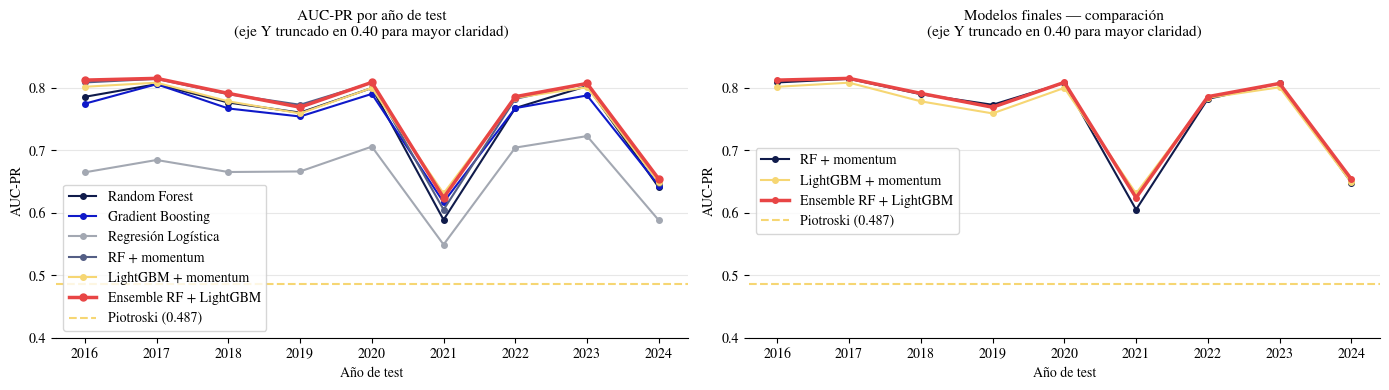

In [15]:
# 9.1 AUC-PR por fold — evolución temporal
# Nota: el eje Y comienza en 0.40 para facilitar la lectura de diferencias entre modelos.
# El valor mínimo teórico es 0.482 (baseline aleatorio).

colores_modelos = {
    "Random Forest":           juan_colors[0],
    "Gradient Boosting":       juan_colors[4],
    "Regresión Logística":     juan_colors[2],
    "RF + momentum":           juan_colors[1],
    "LightGBM + momentum":     juan_colors[5],
    "Ensemble RF + LightGBM":  "#E84545",
}

anos = list(range(2016, 2025))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel izquierdo — todos los modelos
estilo_ax(axes[0])
for nombre, color in colores_modelos.items():
    if nombre in resultados:
        vals = [f["auc_pr"] for f in resultados[nombre]]
        lw = 2.5 if "Ensemble" in nombre else 1.5
        axes[0].plot(anos, vals, marker="o", markersize=4,
                     linewidth=lw, color=color, label=nombre)

# Agregar momentum y ensemble
for nombre, folds_res in resultados_momentum.items():
    vals = [f["auc_pr"] for f in folds_res]
    axes[0].plot(anos, vals, marker="o", markersize=4, linewidth=1.5,
                 color=colores_modelos.get(nombre, juan_colors[1]), label=nombre)

vals_ens = [f["auc_pr"] for f in resultados_ensemble]
axes[0].plot(anos, vals_ens, marker="o", markersize=5, linewidth=2.5,
             color="#E84545", label="Ensemble RF + LightGBM", zorder=5)

axes[0].axhline(0.487, color=juan_colors[5], linewidth=1.5,
                linestyle="--", label="Piotroski (0.487)")
axes[0].set_title("AUC-PR por año de test\n(eje Y truncado en 0.40 para mayor claridad)",
                  fontfamily=FUENTE, fontsize=11)
axes[0].set_xlabel("Año de test", fontfamily=FUENTE)
axes[0].set_ylabel("AUC-PR", fontfamily=FUENTE)
axes[0].set_xticks(anos)
axes[0].set_ylim(0.40, 0.87)
axes[0].legend(prop={"family": FUENTE}, fontsize=7)

# Panel derecho — solo modelos finales
estilo_ax(axes[1])
modelos_finales = {
    "RF + momentum":          [f["auc_pr"] for f in resultados_momentum["RF + momentum"]],
    "LightGBM + momentum":    [f["auc_pr"] for f in resultados_momentum["LightGBM + momentum"]],
    "Ensemble RF + LightGBM": [f["auc_pr"] for f in resultados_ensemble],
}
colores_finales = [juan_colors[0], juan_colors[5], "#E84545"]

for (nombre, vals), color in zip(modelos_finales.items(), colores_finales):
    lw = 2.5 if "Ensemble" in nombre else 1.5
    axes[1].plot(anos, vals, marker="o", markersize=4,
                 linewidth=lw, color=color, label=nombre)

axes[1].axhline(0.487, color=juan_colors[5], linewidth=1.5,
                linestyle="--", label="Piotroski (0.487)")
axes[1].set_title("Modelos finales — comparación\n(eje Y truncado en 0.40 para mayor claridad)",
                  fontfamily=FUENTE, fontsize=11)
axes[1].set_xlabel("Año de test", fontfamily=FUENTE)
axes[1].set_ylabel("AUC-PR", fontfamily=FUENTE)
axes[1].set_xticks(anos)
axes[1].set_ylim(0.40, 0.87)
axes[1].legend(prop={"family": FUENTE}, fontsize=8)

plt.tight_layout()
plt.show()

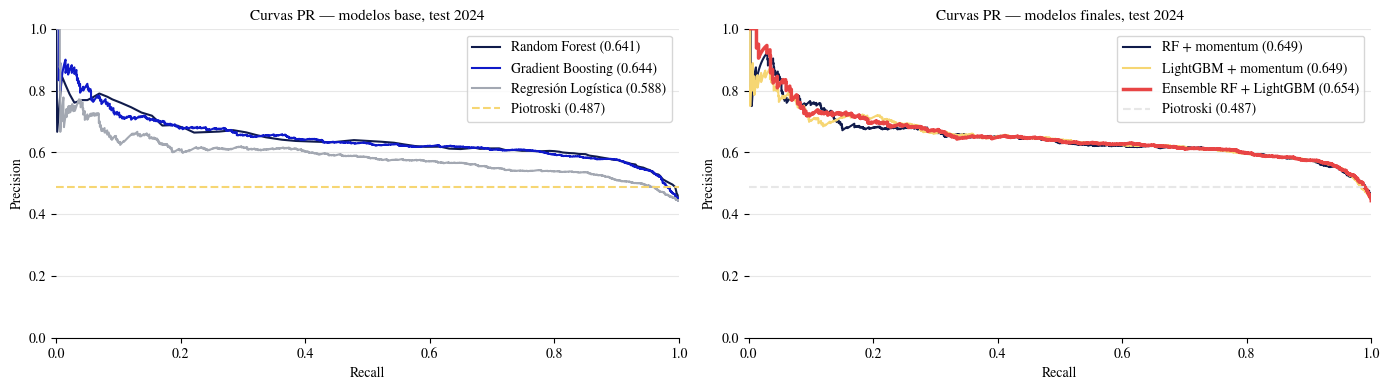

In [16]:
# 9.2 Curvas Precision-Recall — último fold (2024)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel izquierdo — todos los modelos en 2024
estilo_ax(axes[0])
for nombre, color in [
    ("Random Forest",    juan_colors[0]),
    ("Gradient Boosting", juan_colors[4]),
    ("Regresión Logística", juan_colors[2]),
]:
    fold = resultados[nombre][-1]
    p, r, _ = precision_recall_curve(fold["y_test"], fold["y_prob"])
    auc = average_precision_score(fold["y_test"], fold["y_prob"])
    axes[0].plot(r, p, linewidth=1.5, color=color, label=f"{nombre} ({auc:.3f})")

axes[0].axhline(0.487, color=juan_colors[5], linewidth=1.5,
                linestyle="--", label="Piotroski (0.487)")
axes[0].set_title("Curvas PR — modelos base, test 2024",
                  fontfamily=FUENTE, fontsize=11)
axes[0].set_xlabel("Recall", fontfamily=FUENTE)
axes[0].set_ylabel("Precision", fontfamily=FUENTE)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend(prop={"family": FUENTE}, fontsize=8)

# Panel derecho — modelos finales en 2024
estilo_ax(axes[1])
fold_rf   = resultados_momentum["RF + momentum"][-1]
fold_lgbm = resultados_momentum["LightGBM + momentum"][-1]
fold_ens  = resultados_ensemble[-1]

for fold, nombre, color in [
    (fold_rf,   "RF + momentum",          juan_colors[0]),
    (fold_lgbm, "LightGBM + momentum",    juan_colors[5]),
    (fold_ens,  "Ensemble RF + LightGBM", "#E84545"),
]:
    p, r, _ = precision_recall_curve(fold["y_test"], fold["y_prob"])
    auc = average_precision_score(fold["y_test"], fold["y_prob"])
    lw = 2.5 if "Ensemble" in nombre else 1.5
    axes[1].plot(r, p, linewidth=lw, color=color, label=f"{nombre} ({auc:.3f})")

axes[1].axhline(0.487, color=juan_colors[3], linewidth=1.5,
                linestyle="--", label="Piotroski (0.487)")
axes[1].set_title("Curvas PR — modelos finales, test 2024",
                  fontfamily=FUENTE, fontsize=11)
axes[1].set_xlabel("Recall", fontfamily=FUENTE)
axes[1].set_ylabel("Precision", fontfamily=FUENTE)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend(prop={"family": FUENTE}, fontsize=8)

plt.tight_layout()
plt.show()

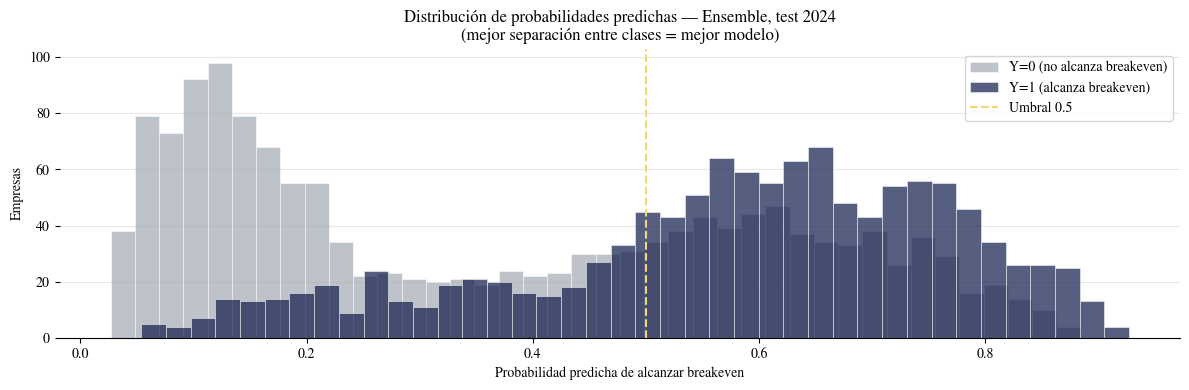

In [17]:
# 9.3 Distribución de probabilidades predichas — ensemble en 2024
fold_ens_2024 = resultados_ensemble[-1]
y_test_2024   = fold_ens_2024["y_test"]
y_prob_2024   = fold_ens_2024["y_prob"]

fig, ax = plt.subplots(figsize=(12, 4))
estilo_ax(ax)

ax.hist(y_prob_2024[y_test_2024 == 0], bins=40, alpha=0.7,
        color=juan_colors[2], label="Y=0 (no alcanza breakeven)",
        edgecolor="white", linewidth=0.5)
ax.hist(y_prob_2024[y_test_2024 == 1], bins=40, alpha=0.7,
        color=juan_colors[0], label="Y=1 (alcanza breakeven)",
        edgecolor="white", linewidth=0.5)
ax.axvline(0.5, color=juan_colors[5], linewidth=1.5,
           linestyle="--", label="Umbral 0.5")
ax.set_title("Distribución de probabilidades predichas — Ensemble, test 2024\n"
             "(mejor separación entre clases = mejor modelo)",
             fontfamily=FUENTE, fontsize=12)
ax.set_xlabel("Probabilidad predicha de alcanzar breakeven", fontfamily=FUENTE)
ax.set_ylabel("Empresas", fontfamily=FUENTE)
ax.legend(prop={"family": FUENTE})
plt.tight_layout()
plt.show()

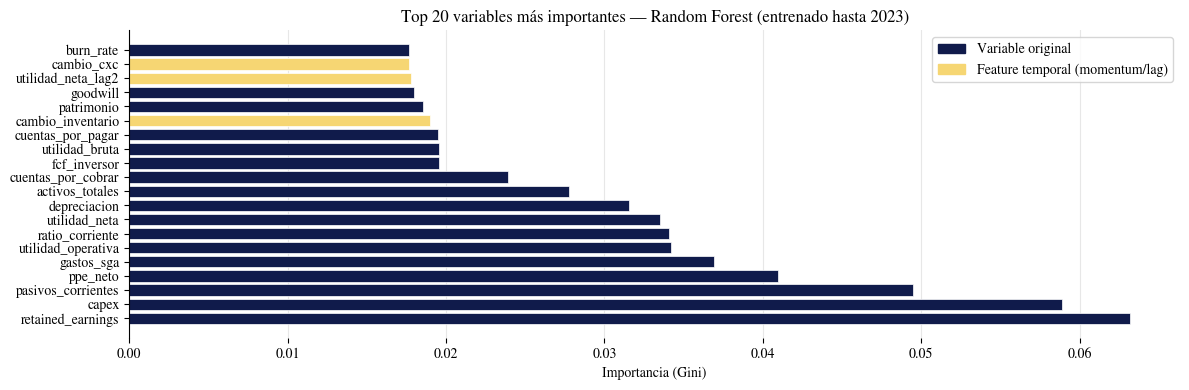

In [18]:
# 9.4 Importancia de variables — modelo final
train_final = df[df["ano"] < 2024].copy()
rf_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=10,
        random_state=42, n_jobs=-1))
])
rf_final.fit(train_final[features_con_momentum].values, train_final["Y"].values)

importancias = pd.Series(
    rf_final.named_steps["model"].feature_importances_,
    index=features_con_momentum
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
estilo_ax(ax, "horizontal")

top20 = importancias.head(20)
colores_imp = [juan_colors[5] if "cambio" in v or "lag" in v
               else juan_colors[0] for v in top20.index]
ax.barh(top20.index, top20.values,
        color=colores_imp, edgecolor="white", linewidth=0.5)

patch_orig  = mpatches.Patch(color=juan_colors[0], label="Variable original")
patch_tempo = mpatches.Patch(color=juan_colors[5], label="Feature temporal (momentum/lag)")
ax.legend(handles=[patch_orig, patch_tempo], prop={"family": FUENTE})
ax.set_title("Top 20 variables más importantes — Random Forest (entrenado hasta 2023)",
             fontfamily=FUENTE, fontsize=12)
ax.set_xlabel("Importancia (Gini)", fontfamily=FUENTE)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
plt.tight_layout()
plt.show()

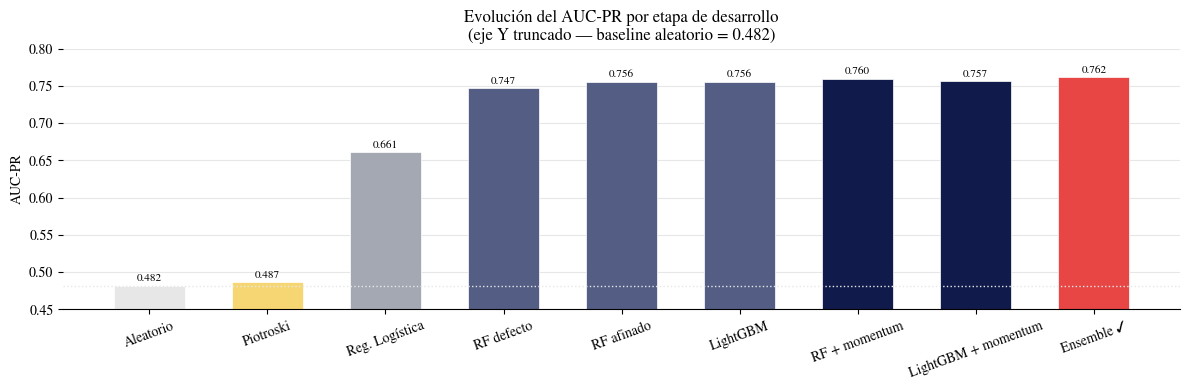

In [19]:
# 9.5 Evolución del AUC-PR — gráfico de barras por etapa de desarrollo
etapas = [
    ("Aleatorio",            0.482),
    ("Piotroski",            0.487),
    ("Reg. Logística",       0.661),
    ("RF defecto",           0.747),
    ("RF afinado",           0.756),
    ("LightGBM",             0.756),
    ("RF + momentum",        0.760),
    ("LightGBM + momentum",  0.757),
    ("Ensemble ✓",           0.762),
]

nombres_etapas = [e[0] for e in etapas]
valores_etapas = [e[1] for e in etapas]
colores_etapas = [
    juan_colors[3],  # Aleatorio
    juan_colors[5],  # Piotroski
    juan_colors[2],  # Reg. Logística
    juan_colors[1],  # RF defecto
    juan_colors[1],  # RF afinado
    juan_colors[1],  # LightGBM
    juan_colors[0],  # RF + momentum
    juan_colors[0],  # LightGBM + momentum
    "#E84545",       # Ensemble
]

fig, ax = plt.subplots(figsize=(12, 4))
estilo_ax(ax)
bars = ax.bar(nombres_etapas, valores_etapas,
              color=colores_etapas, edgecolor="white", linewidth=0.5, width=0.6)
ax.set_ylim(0.45, 0.80)
ax.axhline(0.482, color=juan_colors[3], linewidth=1.0, linestyle=":")

for bar, val in zip(bars, valores_etapas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", va="bottom",
            fontfamily=FUENTE, fontsize=8)

ax.set_title("Evolución del AUC-PR por etapa de desarrollo\n"
             "(eje Y truncado — baseline aleatorio = 0.482)",
             fontfamily=FUENTE, fontsize=12)
ax.set_ylabel("AUC-PR", fontfamily=FUENTE)
ax.tick_params(axis="x", rotation=20)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
plt.tight_layout()
plt.show()

## 10. Resultados

### Tabla comparativa completa

| Modelo | AUC-PR Media | Std | Mín | Máx |
|---|---|---|---|---|
| **Ensemble RF + LightGBM ✓** | **0.762** | **0.067** | **0.624** | **0.818** |
| RF + momentum | 0.760 | 0.072 | 0.606 | 0.819 |
| LightGBM + momentum | 0.757 | 0.063 | 0.630 | 0.808 |
| RF afinado | 0.756 | 0.073 | 0.599 | 0.820 |
| LightGBM (base) | 0.756 | 0.063 | 0.632 | 0.811 |
| XGBoost (base) | 0.755 | 0.065 | 0.623 | 0.813 |
| GB afinado | 0.755 | 0.064 | 0.622 | 0.811 |
| RF defecto | 0.747 | 0.080 | 0.582 | 0.806 |
| GB defecto | 0.746 | 0.067 | 0.618 | 0.806 |
| Regresión Logística | 0.661 | 0.057 | 0.549 | 0.723 |
| Piotroski (benchmark) | 0.487 | — | — | — |
| Aleatorio (baseline) | 0.482 | — | — | — |

### Interpretación

El modelo final — **Ensemble de Random Forest y LightGBM con features de momentum** — alcanza un AUC-PR promedio de 0.762 sobre 9 folds de walk-forward validation. Esto representa:

- Una mejora del **58% sobre el baseline aleatorio** (0.482)
- Una mejora del **56% sobre el Piotroski F-Score** (0.487), el método tradicional de referencia en value investing cuantitativo
- Una mejora del **15% sobre la Regresión Logística** (0.661), confirmando que los patrones de breakeven son no lineales

Este resultado es consistente con la literatura de ML aplicado a predicción financiera. Gu, Kelly & Xiu (2020) reportan mejoras comparables sobre benchmarks tradicionales para predicción de retornos accionarios en el mercado estadounidense. La superioridad de los modelos de árboles sobre la regresión lineal confirma que la relación entre variables financieras y el breakeven de FCF involucra interacciones complejas que los modelos lineales no capturan.

### Sobre el AUC-PR de 2024

El AUC-PR del último fold (2024, ~0.64) es algo menor al promedio histórico. Esto refleja que los patrones financieros recientes — en un entorno de tasas de interés elevadas post-2022 — difieren parcialmente de los períodos de entrenamiento. Este fenómeno, conocido como *concept drift*, es inherente a la predicción financiera y no invalida el modelo: es honestidad metodológica sobre los límites de generalización temporal. En la práctica, un inversionista reentrenarí­a el modelo periódicamente incorporando los datos más recientes.

## 11. Guardar modelo final y predicciones

In [20]:
import pickle

# Reentrenar ensemble con todos los datos disponibles (hasta 2024)
X_todo = df[features_con_momentum].values
y_todo = df["Y"].values

rf_final_completo = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=10,
        random_state=42, n_jobs=-1))
])
lgbm_final_completo = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   LGBMClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.05,
        min_child_samples=10, random_state=42, verbose=-1))
])

rf_final_completo.fit(X_todo, y_todo)
lgbm_final_completo.fit(X_todo, y_todo)

# Guardar modelos
Path("../salidas").mkdir(exist_ok=True)
with open("../salidas/modelo_rf_final.pkl", "wb") as f:
    pickle.dump(rf_final_completo, f)
with open("../salidas/modelo_lgbm_final.pkl", "wb") as f:
    pickle.dump(lgbm_final_completo, f)

# Guardar features de momentum para reproducibilidad
pd.Series(features_con_momentum).to_csv("../salidas/features_modelo.csv", index=False)

# Guardar resultados del walk-forward
df_wf = pd.DataFrame([
    {"modelo": "Ensemble RF + LightGBM",
     "ano_test": f["ano_test"],
     "auc_pr": f["auc_pr"]}
    for f in resultados_ensemble
])
df_wf.to_csv("../salidas/resultados_walkforward.csv", index=False)

print("Modelos y resultados guardados en salidas/")
print(f"\nFeatures del modelo final: {len(features_con_momentum)}")
print(f"AUC-PR promedio final:     {np.mean(vals_ens):.3f}")
print(f"Mejora vs aleatorio:       +{(np.mean(vals_ens) - 0.482)/0.482*100:.0f}%")
print(f"Mejora vs Piotroski:       +{(np.mean(vals_ens) - 0.487)/0.487*100:.0f}%")

Modelos y resultados guardados en salidas/

Features del modelo final: 65
AUC-PR promedio final:     0.763
Mejora vs aleatorio:       +58%
Mejora vs Piotroski:       +57%
